In [1]:
# data stuff
import xarray as xr
import numpy as np
import pandas as pd
#import dask.array as da
import dask

# date stuff
import warnings
warnings.filterwarnings('ignore')
from datetime import date
import cftime

# Plotting libraries
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.font_manager import FontProperties
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import cmocean
from matplotlib import cm

import string
from matplotlib.lines import Line2D

In [2]:
# hfdrake_path = "/pub/hfdrake/datasets/CM4_MHW_blobs/"
model_data_path = "/dfs9/hfdrake_hpc/datasets/CM4_MHW_blobs/"
path = "/pub/mariant3/WarmWaterMasses/data/"

labels = (xr.open_dataset(
    f"{path}ocetrac-v9-blobs-tos-t1-r1-msq0-01860315-01891214-region.nc").sel(
    time=slice(f"0186", f"0189"))).blobs.load();

ds = xr.open_dataset(f"{model_data_path}data/ocean_daily_cmip.01860101-01901231.tos.nc", chunks={'time':100})
static = xr.open_dataset(f"{model_data_path}data/ocean_daily_cmip.static.nc")
ds_region = ds.sel(xh=slice(labels.xh.min(), labels.xh.max()), yh=slice(labels.yh.min(), labels.yh.max()))
static_region = static.sel(xh=slice(labels.xh.min(), labels.xh.max()), yh=slice(labels.yh.min(), labels.yh.max()))
ds_static_region = xr.merge([static_region,ds_region])

ids = np.unique(labels)
ids = np.array([id for id in ids if ~np.isnan(id)])

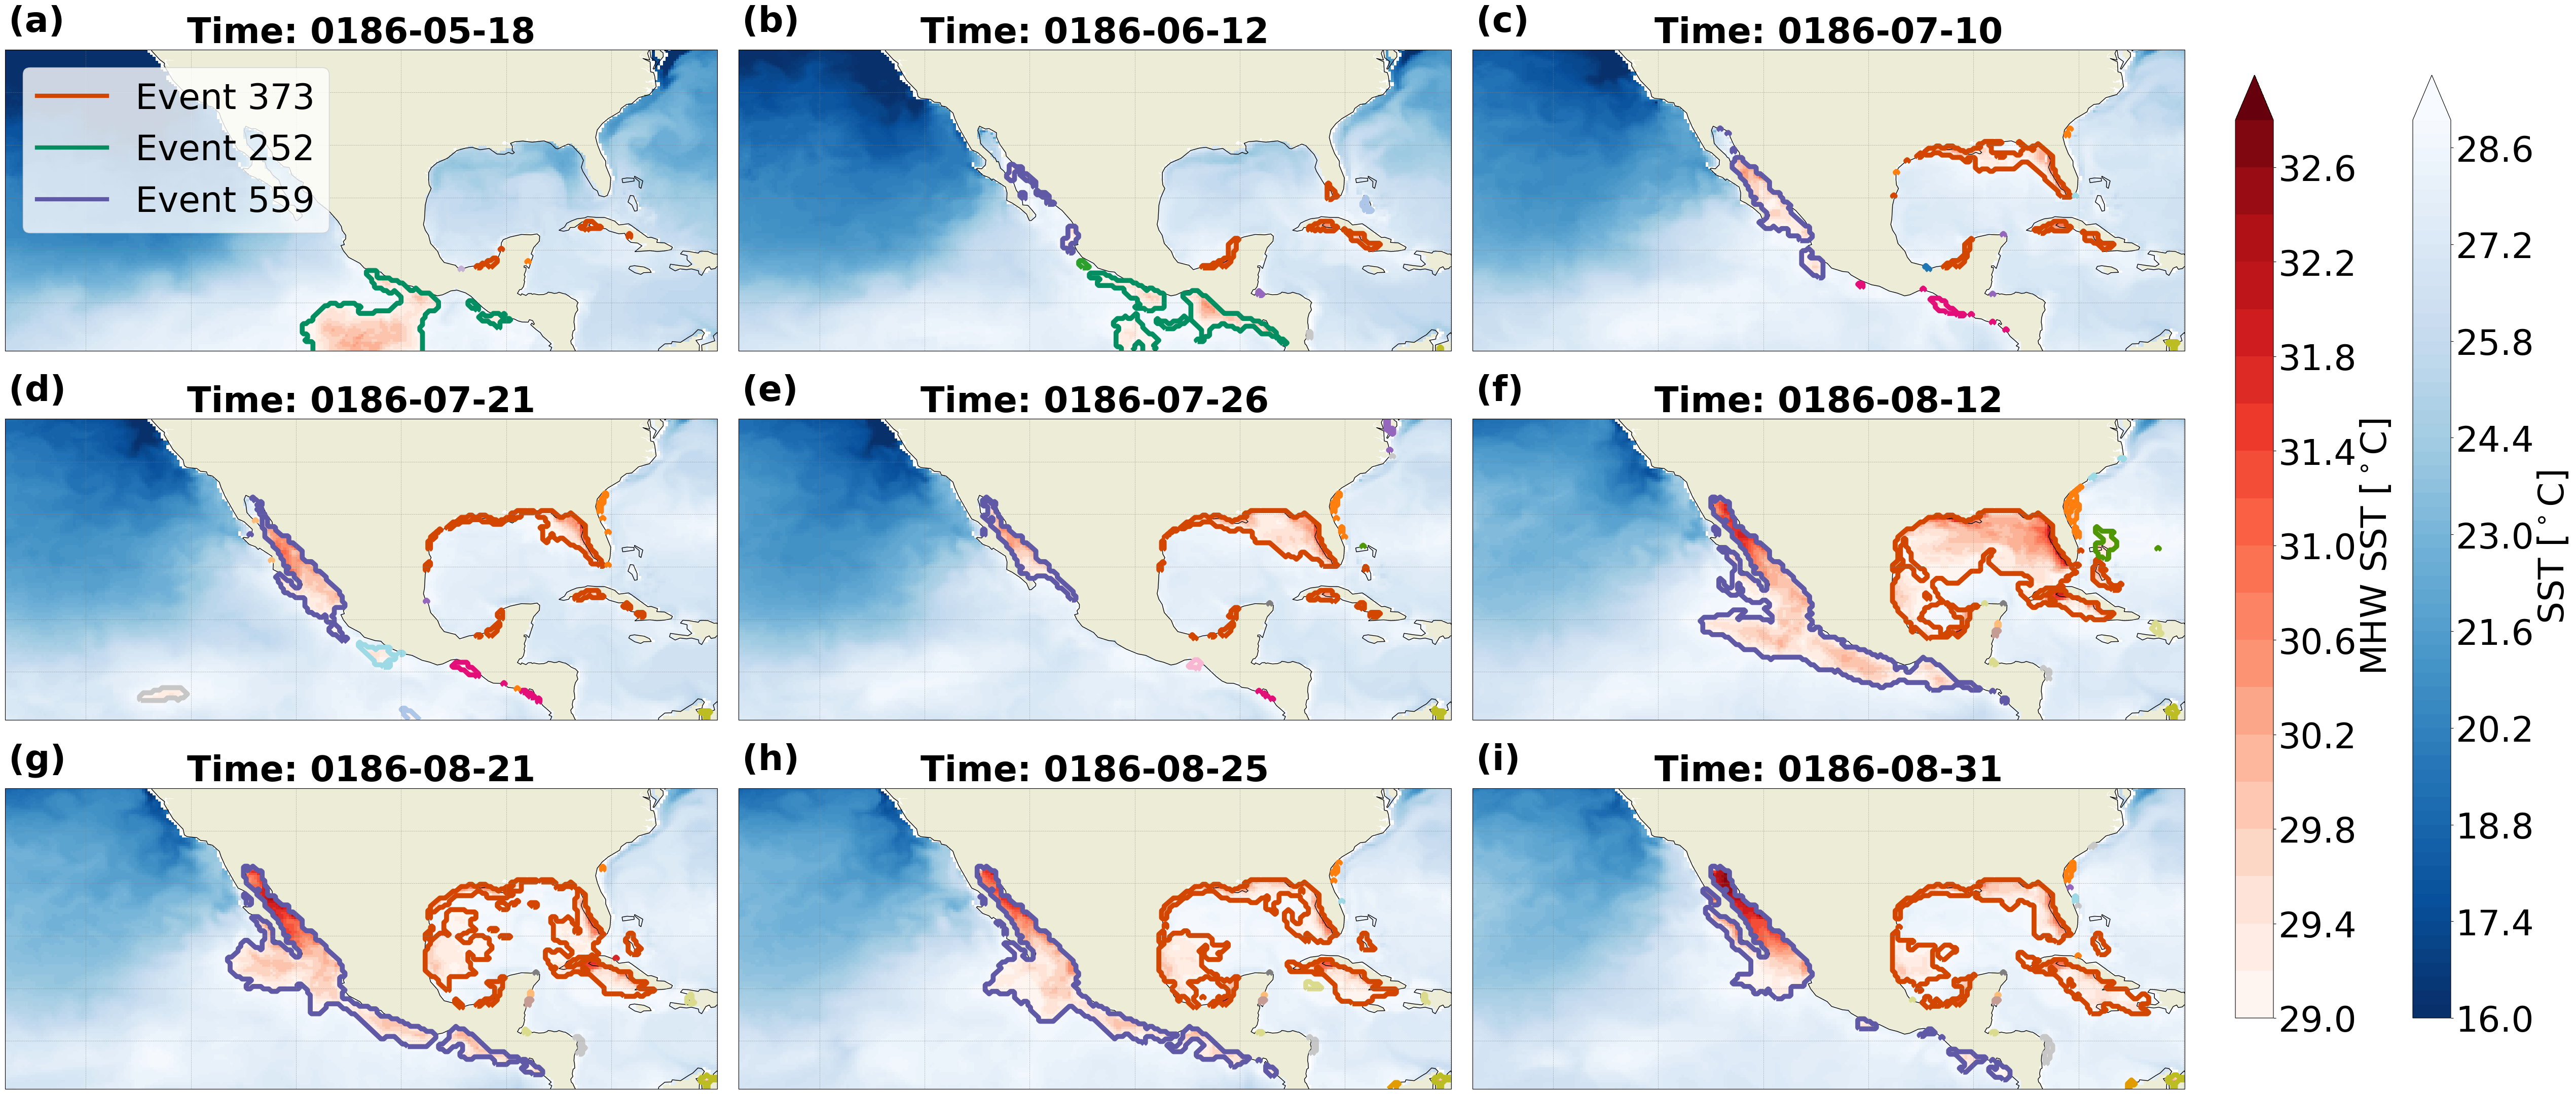

In [3]:
tab20_colors = plt.cm.tab20(np.linspace(0, 1, 50))
tab20_hex = ['#%02x%02x%02x' % tuple((color[:3] * 255).astype(int)) for color in tab20_colors]

custom_colors_all = {
    252: '#038E62', 373: '#D34600', 559: '#6059A6', 723: '#E30E78',
    986: '#4F9704', 1071: '#E19D00', 1467: '#986204', 2096: '#F65D77',
    2253: '#C57E16', 2478: '#869415', 2883: '#16A34F', 3984: '#E10D10',
    4113: '#1B69AC', 4350: '#33A130', 5987: '#50B797', 6070: '#FC7B4C',
    7088: '#7A90C2', 7122: '#E377B8', 7196: '#97D13B'
}

def get_color_for_id(id_val, custom_colors, tab20_colors_hex):
    if int(id_val) in custom_colors:
        return custom_colors[int(id_val)]
    color_index = hash(int(id_val)) % len(tab20_colors_hex)
    return tab20_colors_hex[color_index]

days_row1 = ['0186-05-18', '0186-06-12', '0186-07-10']
days_row2 = ['0186-07-21', '0186-07-26', '0186-08-12']
days_row3 = ['0186-08-21', '0186-08-25', '0186-08-31']
all_days = days_row1 + days_row2 + days_row3

fontsize = 50

fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(50, 30),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.subplots_adjust(
    left=0.04,
    right=0.90,
    top=0.92,
    bottom=0.03,
    hspace=-0.4,
    wspace=0.03
)

axes = axes.flatten()

for i, day in enumerate(all_days):

    ax = axes[i]
    ax.add_feature(cfeature.LAND, facecolor='#ececd7', zorder=0)

    try:
        sst_full = ds_region.tos.isel(
            time=ds_region.time.get_index("time").get_loc(day).start
        )
    except KeyError:
        print(f"Day {day} not found in dataset. Skipping.")
        continue

    # panel label
    ax.text(
        0.005, 1.15,
        f"({string.ascii_lowercase[i]})",
        transform=ax.transAxes,
        fontsize=fontsize,
        va='top',
        ha='left',
        fontweight='bold'
    )

    # base SST
    s = sst_full.plot(
        ax=ax,
        cmap="Blues_r",
        levels=np.arange(16, 29.01, 0.2),
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )

    mask_day = labels.isel(
        time=labels.time.get_index("time").get_loc(day).start
    )

    # event contours
    for id_val in ids:
        contour_color = get_color_for_id(id_val, custom_colors_all, tab20_hex)
        event_mask = mask_day.where(mask_day == id_val, drop=False)

        if event_mask.notnull().any():
            binary_mask = event_mask.notnull().astype(int)
            binary_mask.plot.contour(
                ax=ax,
                levels=[0.5],
                colors=[contour_color],
                linewidths=7,
                transform=ccrs.PlateCarree()
            )

    # masked MHW SST
    mask_filtered = np.isin(mask_day, ids)
    sst_masked = sst_full.where(mask_filtered, drop=False)

    p = sst_masked.plot(
        ax=ax,
        cmap="Reds",
        levels=np.arange(29, 33, 0.2),
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )

    # stars
    # ax.plot(
    #     -107, 19,
    #     color=get_color_for_id(559, custom_colors_all, tab20_hex),
    #     marker='*',
    #     markeredgecolor='k',
    #     markersize=34,
    #     markeredgewidth=1,
    #     transform=ccrs.PlateCarree(),
    #     zorder=100
    # )

    # ax.plot(
    #     -84, 27,
    #     color=get_color_for_id(373, custom_colors_all, tab20_hex),
    #     marker='*',
    #     markeredgecolor='k',
    #     markersize=34,
    #     markeredgewidth=1,
    #     transform=ccrs.PlateCarree(),
    #     zorder=100
    # )

    # ax.plot(
    #     -93.5, 15,
    #     color=get_color_for_id(252, custom_colors_all, tab20_hex),
    #     marker='*',
    #     markeredgecolor='k',
    #     markersize=34,
    #     markeredgewidth=1,
    #     transform=ccrs.PlateCarree(),
    #     zorder=100
    # )

    # map framing
    ax.set_xlim([labels.xh.min(), labels.xh.max()])
    ax.set_ylim([labels.yh.min(), labels.yh.max()])
    ax.set_title(f"Time: {day}", fontsize=fontsize, fontweight='bold')
    ax.coastlines(resolution="110m", color='k')

    gl = ax.gridlines(
        draw_labels=False,
        linewidth=0.5,
        color='gray',
        alpha=0.6,
        linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False

    # legend only once
    if i == 0:
        legend_handles = [
            Line2D([0], [0],
                   color=get_color_for_id(373, custom_colors_all, tab20_hex),
                   lw=6,
                   label='Event 373'),

            Line2D([0], [0],
                   color=get_color_for_id(252, custom_colors_all, tab20_hex),
                   lw=6,
                   label='Event 252'),

            Line2D([0], [0],
                   color=get_color_for_id(559, custom_colors_all, tab20_hex),
                   lw=6,
                   label='Event 559'),

            # Line2D([0], [0],
            #        marker='*',
            #        color=get_color_for_id(559, custom_colors_all, tab20_hex),
            #        markeredgecolor='k',
            #        linestyle='None',
            #        markersize=25,
            #        label='Subsurface location event 559'),

            # Line2D([0], [0],
            #        marker='*',
            #        color=get_color_for_id(373, custom_colors_all, tab20_hex),
            #        markeredgecolor='k',
            #        linestyle='None',
            #        markersize=25,
            #        label='Subsurface location event 373'),

            # Line2D([0], [0],
                   # marker='*',
                   # color=get_color_for_id(252, custom_colors_all, tab20_hex),
                   # markeredgecolor='k',
                   # linestyle='None',
                   # markersize=25,
                   # label='Subsurface location event 252')
        ]

        ax.legend(
            handles=legend_handles,
            loc='upper left',
            fontsize=fontsize,
            frameon=True
        )


cb_mhw_ax = fig.add_axes([0.92, 0.18, 0.015, 0.62])
cbar = fig.colorbar(p, cax=cb_mhw_ax, orientation='vertical')
cbar.ax.tick_params(labelsize=fontsize)
cbar.set_label(r'MHW SST [$^\circ$C]', fontsize=fontsize)

cb_sst_ax = fig.add_axes([0.99, 0.18, 0.015, 0.62])
scbar = fig.colorbar(s, cax=cb_sst_ax, orientation='vertical')
scbar.ax.tick_params(labelsize=fontsize)
scbar.set_label(r'SST [$^\circ$C]', fontsize=fontsize)

# plt.savefig("../figures/ocetrac-evo-186_1.png", dpi=400, bbox_inches="tight")
plt.show()